**LeNet 1998**
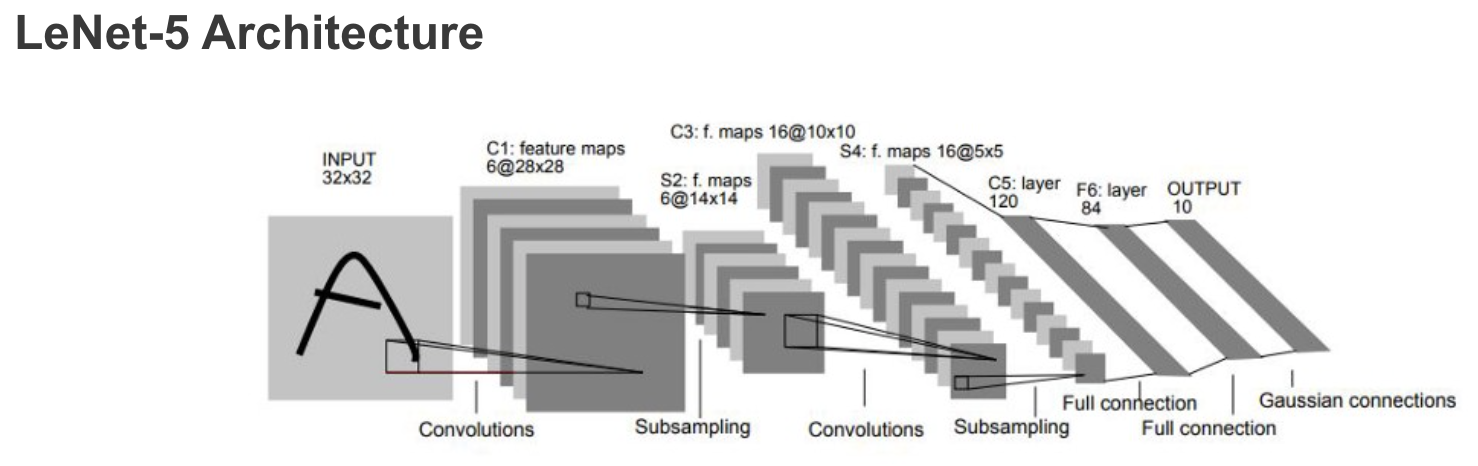

In [19]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [21]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [22]:
sample_shape = x_train[0].shape
img_width, img_height = sample_shape[0], sample_shape[1]
input_shape = (img_width, img_height, 1)

x_train = x_train.reshape(len(x_train), input_shape[0], input_shape[1], input_shape[2])
x_test  = x_test.reshape(len(x_test), input_shape[0], input_shape[1], input_shape[2])

print(x_train.shape)
print(x_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [23]:
print(y_train[0])

5


In [24]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [25]:
print(y_train[0])

[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


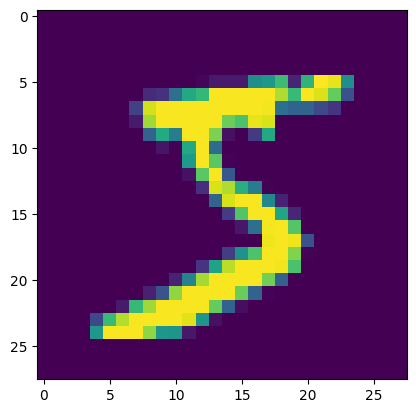

[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


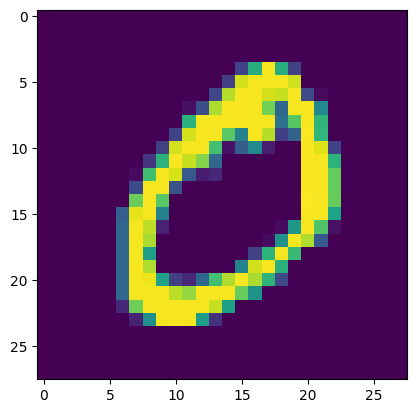

[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


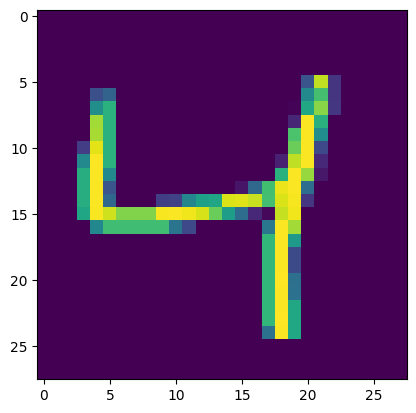

[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]


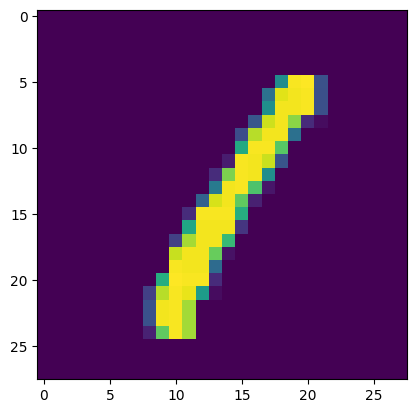

[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]


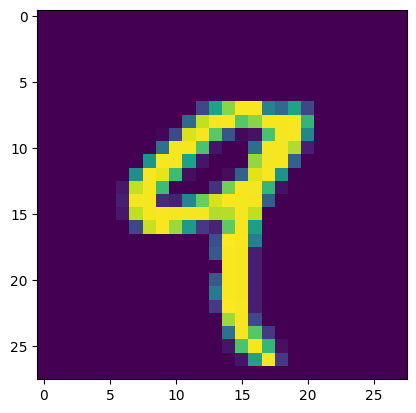

[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


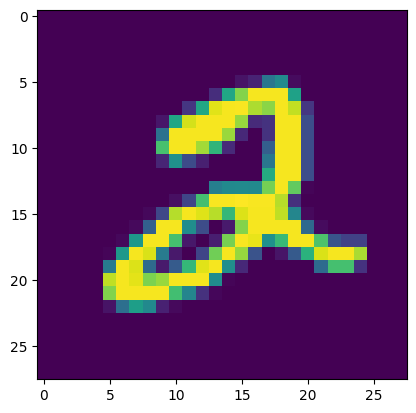

[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]


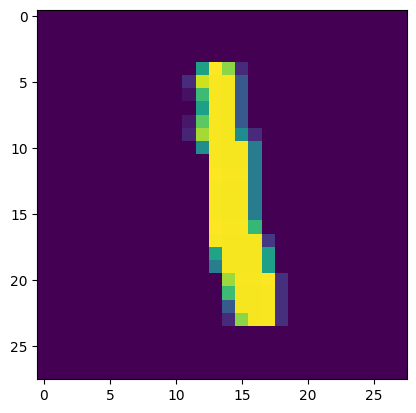

[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]


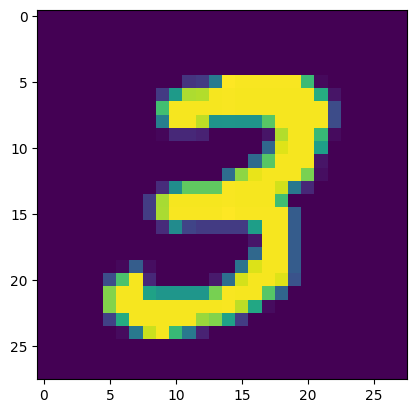

[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]


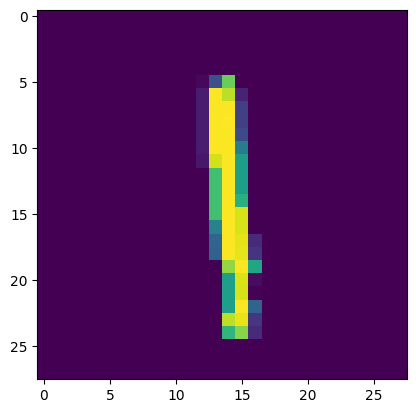

[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]


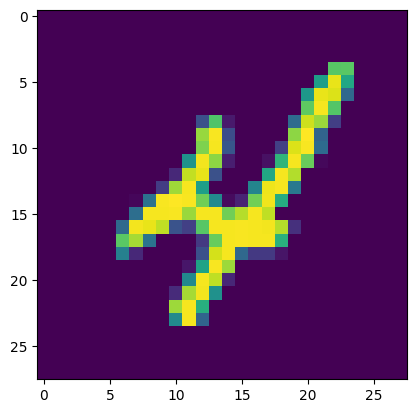

[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]


In [26]:
for i in range(10):
  plt.imshow(x_train[i])
  plt.show()
  print(y_train[i])

In [27]:
LeNet5 = keras.models.Sequential([
    keras.layers.Conv2D(64, 5, activation="relu", padding="same",
                       input_shape=[28,28,1]),
    keras.layers.MaxPooling2D(2),
    keras.layers.Conv2D(32, 3, activation="relu", padding="same"),
    keras.layers.MaxPooling2D(2),
    keras.layers.Conv2D(16, 3, activation="relu", padding="same"),
    keras.layers.MaxPooling2D(2),
    keras.layers.Flatten(),
    keras.layers.Dense(10, activation="relu"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10, activation="softmax")
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
LeNet5.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 16)       │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 3, 3, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 144)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           110 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,312 (102.78 KB)

 Trainable params: 26,312 (102.78 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
LeNet5.compile(loss="categorical_crossentropy", optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001), metrics=['accuracy'])

In [31]:
# LeNet5 = keras.models.Sequential([
#     keras.layers.Conv2D(64, 5, activation="relu", padding="same",
#                        input_shape=[28,28,1]),
#     keras.layers.MaxPooling2D(2),
#     keras.layers.Conv2D(32, 3, activation="relu", padding="same"),
#     keras.layers.MaxPooling2D(2),
#     keras.layers.Conv2D(16, 3, activation="relu", padding="same"),
#     keras.layers.MaxPooling2D(2),
#     keras.layers.Flatten(),
#     keras.layers.Dense(10, activation="relu"),
#     keras.layers.Dropout(0.5),
#     keras.layers.Dense(10, activation="softmax")
# ])

# LeNet5.load_weights('/content/drive/MyDrive/FMAT/MIA/Introduccion_IA/Notebooks/LeNet-5_weights.h5')

iterations = 10
batch_size = 100

start = 0

for step in range(iterations):
  stop = start + batch_size

  images = x_train[start: stop]
  images_label = y_train[start: stop]

  LeNet5_loss = LeNet5.train_on_batch(images, images_label)
  LeNet5_test = LeNet5.test_on_batch(x_test, y_test)
  print(LeNet5_loss, LeNet5_test)

  start += batch_size
  if start > len(x_train) - batch_size:
    start = 0

  if step % 5 == 0:
    LeNet5.save_weights('/content/drive/MyDrive/FMAT/MIA/Introduccion_IA/Notebooks/LeNet-5.weights.h5')

[array(3.6678262, dtype=float32), array(0.10127451, dtype=float32)] [array(5.329987, dtype=float32), array(0.09777228, dtype=float32)]
[array(5.3352294, dtype=float32), array(0.09783252, dtype=float32)] [array(7.0475783, dtype=float32), array(0.0979538, dtype=float32)]
[array(7.0636954, dtype=float32), array(0.09786184, dtype=float32)] [array(5.912232, dtype=float32), array(0.10413367, dtype=float32)]
[array(5.904054, dtype=float32), array(0.10419753, dtype=float32)] [array(5.1915774, dtype=float32), array(0.10639604, dtype=float32)]
[array(5.1858697, dtype=float32), array(0.10646245, dtype=float32)] [array(4.71063, dtype=float32), array(0.1079208, dtype=float32)]
[array(4.706715, dtype=float32), array(0.10795717, dtype=float32)] [array(4.366902, dtype=float32), array(0.10884017, dtype=float32)]
[array(4.3639855, dtype=float32), array(0.10884181, dtype=float32)] [array(4.109066, dtype=float32), array(0.10950495, dtype=float32)]
[array(4.106834, dtype=float32), array(0.10946848, dtype=f

In [32]:
test_loss, test_accuracy = LeNet5.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.1016 - loss: 2.3043
